# Modelo Bi-LSTM

In [1]:
import pandas as pd
df = pd.read_csv('df_exportado.csv')

## Labels e split

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold, train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"A usar: {device}")

label_map = {'Human':0,'OpenAI':1,'Google':2,'Meta':3,'Anthropic':4}
y = df['Label'].map(label_map).values
num_classes = 5

train_texts, test_texts, y_train, y_test = train_test_split(
    df['Text'], y, test_size=0.2, random_state=42, stratify=y
)

A usar: cuda


## Vetorização

In [3]:
from collections import Counter
import re

print("A criar vocabulário e a processar sequências...")

# Parâmetros para as sequências
max_words = 1000000  # Tamanho do vocabulário
max_seq_length = 500  # Tamanho máximo de cada texto (em palavras)

# 1. Função simples de tokenização
def tokenize(text):
    # Limpa um bocado o texto e separa por palavras
    return re.findall(r'\b\w+\b', str(text).lower())

# 2. Criar o vocabulário com as palavras mais comuns do treino
todas_as_palavras = [palavra for texto in train_texts for palavra in tokenize(texto)]
contagem = Counter(todas_as_palavras)

# Dicionário de palavra -> ID (0 é reservado para Padding, 1 para Unknown/Desconhecido)
vocab = {palavra: i+2 for i, (palavra, _) in enumerate(contagem.most_common(max_words - 2))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

# 3. Função para converter texto em sequência de IDs com Padding
def encode_and_pad(text):
    tokens = tokenize(text)
    # Converte para IDs (se não existir no vocab, usa 1)
    seq = [vocab.get(word, 1) for word in tokens]
    
    # Truncar (cortar) se for maior que o limite
    if len(seq) > max_seq_length:
        seq = seq[:max_seq_length]
    # Padding (preencher com 0s) se for menor que o limite
    else:
        seq = seq + [0] * (max_seq_length - len(seq))
    return seq

# 4. Transformar os dados de treino
X_train_seq = [encode_and_pad(t) for t in train_texts]
y_train_np = np.array(y_train)

# Transformar para tensores PyTorch
# IMPORTANTE: Para o nn.Embedding da LSTM, os inputs têm de ser do tipo torch.long (inteiros)
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.long)

print(f"Shape do X_train_tensor: {X_train_tensor.shape}") # Deve ser (num_exemplos, max_seq_length)

A criar vocabulário e a processar sequências...
Shape do X_train_tensor: torch.Size([197304, 500])


## Modelo

In [4]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        
        # 1. Camada Embedding: Transforma o ID da palavra num vetor denso (ex: 128 dimensões)
        # padding_idx=0 diz ao modelo para ignorar os zeros que adicionamos
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. A Camada Bi-LSTM
        # batch_first=True porque os nossos tensores têm o batch size na primeira dimensão (batch, seq_len)
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=num_layers, 
            bidirectional=True, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # 3. Camadas Densas para Classificação
        # Multiplicamos hidden_dim por 2 porque a LSTM é bidirecional (junta a leitura da esquerda->direita com direita->esquerda)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_length)
        
        # Passa pelo embedding
        embedded = self.embedding(x) 
        # embedded shape: (batch_size, seq_length, embedding_dim)
        
        # Passa pela LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # hidden contém o último estado oculto. Sendo bidirecional e com 2 camadas, 
        # queremos juntar as saídas da última camada que leu "para a frente" e "para trás".
        # hidden shape: (num_layers * num_directions, batch_size, hidden_dim)
        hidden_forward = hidden[-2, :, :]  # Última camada forward
        hidden_backward = hidden[-1, :, :] # Última camada backward
        
        # Concatenar os dois estados
        hidden_cat = torch.cat((hidden_forward, hidden_backward), dim=1)
        # hidden_cat shape: (batch_size, hidden_dim * 2)
        
        # Passar pelas camadas densas finais
        out = self.fc1(hidden_cat)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

## Funções de Treino e Avaliação

In [5]:
def train_model(model, loader, criterion, optimizer):
    model.train()
    
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        # 1. Acumular a loss do batch
        total_loss += loss.item() * X_batch.size(0)
        
        # 2. Descobrir qual a classe prevista (o índice com maior probabilidade)
        _, preds = torch.max(outputs, dim=1)
        
        # 3. Contar quantas previsões bateram certo com o y_batch
        correct_predictions += torch.sum(preds == y_batch).item()
        total_samples += y_batch.size(0)
        
    # Calcular a média final
    epoch_loss = total_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
    return correct / total

## Grid Search

In [7]:
from sklearn.utils.class_weight import compute_class_weight

param_grid = {
    'learning_rate': [0.0005, 0.001],
    'batch_size': [32, 64],
    'weight_decay': [0.0, 1e-4],      # L2 Regularization
    'epochs': [5]
}
keys, values = zip(*param_grid.items())
configs = [dict(zip(keys, v)) for v in itertools.product(*values)]

print("\nA extrair uma amostra perfeitamente balanceada (Undersampling)...")

# Quantos textos queremos no total para o Grid Search?
total_amostra = 15000
# Dividido por 5 classes = 3000 exemplos de cada classe
amostras_por_classe = total_amostra // num_classes 

indices_balanceados = []

# Vamos buscar uma quantidade igual de índices para cada categoria (0 a 4)
for c in range(num_classes):
    # Encontra todos os índices onde a classe é igual a 'c'
    indices_c = np.where(y_train_tensor.cpu().numpy() == c)[0]
    
    # Se uma classe tiver menos textos que os 3000, apanhamos os que houver
    n_escolher = min(amostras_por_classe, len(indices_c))
    
    # Escolhe aleatoriamente 'n_escolher' índices sem repetição
    amostra_c = np.random.choice(indices_c, size=n_escolher, replace=False)
    indices_balanceados.extend(amostra_c)

# Embaralhar a lista final para que as classes fiquem misturadas
np.random.shuffle(indices_balanceados)

# Converter para formato tensor
indices_balanceados = torch.tensor(indices_balanceados, dtype=torch.long)

# Criar a grelha final com os dados perfeitamente equilibrados
X_grid = X_train_tensor[indices_balanceados]
y_grid = y_train_tensor[indices_balanceados]

print(f"Tamanho da amostra balanceada: {len(y_grid)} textos.")

# ==============================================================
# IMPORTANTE: Como os dados agora estão balanceados artificialmente,
# não precisamos de usar os pesos calculados!
# ==============================================================
pesos = torch.ones(num_classes, dtype=torch.float32).to(device)

kf = KFold(n_splits=3, shuffle=True, random_state=42)

melhor_acc = 0
melhores_params = None


# Hiperparâmetros da arquitetura LSTM
EMBEDDING_DIM = 100
HIDDEN_DIM = 128

print("\nGrid Search Rápido...")
for config in configs:
    fold_acc = []
    for train_idx, val_idx in kf.split(X_grid.numpy()):
        
        train_dataset = TensorDataset(X_grid[train_idx], y_grid[train_idx])
        val_dataset = TensorDataset(X_grid[val_idx], y_grid[val_idx])

        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])

        model = BiLSTM(max_words, EMBEDDING_DIM, HIDDEN_DIM, num_classes, dropout=0.3).to(device)
        
        criterion = nn.CrossEntropyLoss(weight=pesos)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'], weight_decay=config['weight_decay'])

        for epoch in range(config['epochs']):
            train_model(model, train_loader, criterion, optimizer)

        acc = evaluate(model, val_loader)
        fold_acc.append(acc)

    media = np.mean(fold_acc)
    print(f"{config} -> Accuracy: {media:.4f}")

    if media > melhor_acc:
        melhor_acc = media
        melhores_params = config

print("\nMelhores parâmetros:", melhores_params)


A extrair uma amostra perfeitamente balanceada (Undersampling)...
Tamanho da amostra balanceada: 15000 textos.

Grid Search Rápido...
{'learning_rate': 0.0005, 'batch_size': 32, 'weight_decay': 0.0, 'epochs': 5} -> Accuracy: 0.8640
{'learning_rate': 0.0005, 'batch_size': 32, 'weight_decay': 0.0001, 'epochs': 5} -> Accuracy: 0.8175
{'learning_rate': 0.0005, 'batch_size': 64, 'weight_decay': 0.0, 'epochs': 5} -> Accuracy: 0.8173
{'learning_rate': 0.0005, 'batch_size': 64, 'weight_decay': 0.0001, 'epochs': 5} -> Accuracy: 0.8433
{'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0, 'epochs': 5} -> Accuracy: 0.8866
{'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 0.0001, 'epochs': 5} -> Accuracy: 0.8811
{'learning_rate': 0.001, 'batch_size': 64, 'weight_decay': 0.0, 'epochs': 5} -> Accuracy: 0.8734
{'learning_rate': 0.001, 'batch_size': 64, 'weight_decay': 0.0001, 'epochs': 5} -> Accuracy: 0.8076

Melhores parâmetros: {'learning_rate': 0.001, 'batch_size': 32, 'weight_

## Treino Final

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Fazer o split normal primeiro (para garantir que a validação é representativa do mundo real)
X_train_numpy = X_train_tensor.numpy()
y_train_numpy = y_train_tensor.numpy()

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_numpy, y_train_numpy, test_size=0.1, stratify=y_train_numpy, random_state=42
)

# ==========================================
# -> APLICAR UNDERSAMPLING APENAS NO TREINO <-
# ==========================================
print("\nA aplicar undersampling ao conjunto de treino...")

# Descobrir qual é a classe com menos exemplos
contagens_por_classe = np.bincount(y_train_final)
min_amostras = np.min(contagens_por_classe)

indices_balanceados_treino = []

# Guardar 'min_amostras' de cada classe
for c in range(num_classes):
    indices_c = np.where(y_train_final == c)[0]
    amostra_c = np.random.choice(indices_c, size=min_amostras, replace=False)
    indices_balanceados_treino.extend(amostra_c)

# Embaralhar a nova lista
np.random.shuffle(indices_balanceados_treino)

# Atualizar o X_train e y_train para conter apenas a amostra balanceada
X_train_final = X_train_final[indices_balanceados_treino]
y_train_final = y_train_final[indices_balanceados_treino]

print(f"Treino balanceado: {len(y_train_final)} textos no total ({min_amostras} por classe).")
print(f"Validação original : {len(y_val_final)} textos.")

# ==========================================

EMBEDDING_DIM = 100
HIDDEN_DIM = 128
BEST_LR = 0.001
BEST_BS = 32
BEST_WD = 0.0
DROPOUT_RATE = 0.3

# 2. Enviar os dados diretamente para a GPU
X_train_final = torch.tensor(X_train_final, dtype=torch.long).to(device)
y_train_final = torch.tensor(y_train_final, dtype=torch.long).to(device)
X_val_final = torch.tensor(X_val_final, dtype=torch.long).to(device)
y_val_final = torch.tensor(y_val_final, dtype=torch.long).to(device)

train_dataset = TensorDataset(X_train_final, y_train_final)
val_dataset = TensorDataset(X_val_final, y_val_final)

train_loader = DataLoader(train_dataset, batch_size=BEST_BS, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BEST_BS)

# 3. Inicializar o modelo com Dropout
model_final = BiLSTM(max_words, EMBEDDING_DIM, HIDDEN_DIM, num_classes, dropout=DROPOUT_RATE).to(device)

# Como o treino agora está 100% balanceado, a perda normal (sem pesos) é a ideal
criterion = nn.CrossEntropyLoss() 

# 4. Otimizador
optimizer = torch.optim.Adam(model_final.parameters(), lr=BEST_LR, weight_decay=BEST_WD)

melhor_val_acc = 0.0

print("\nTreino final a iniciar...")
for epoch in range(10):
    train_loss, train_acc = train_model(model_final, train_loader, criterion, optimizer)
    
    val_acc = evaluate(model_final, val_loader)
    
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # 5. Salvar os pesos sempre que a validação melhorar
    if val_acc > melhor_val_acc:
        melhor_val_acc = val_acc
        torch.save(model_final.state_dict(), 'melhor_modelo_bilstm.pth')
        print(f"  -> Novo melhor modelo salvo! (Val Acc: {val_acc:.4f})")

print("\nTreino Concluído!")
print(f"A melhor acurácia de validação alcançada foi: {melhor_val_acc:.4f}")


A aplicar undersampling ao conjunto de treino...
Treino balanceado: 34030 textos no total (6806 por classe).
Validação original : 19731 textos.

Treino final a iniciar...
Epoch 01 | Train Loss: 0.6621 | Train Acc: 0.7054 | Val Acc: 0.8882
  -> Novo melhor modelo salvo! (Val Acc: 0.8882)
Epoch 02 | Train Loss: 0.2257 | Train Acc: 0.9202 | Val Acc: 0.9034
  -> Novo melhor modelo salvo! (Val Acc: 0.9034)
Epoch 03 | Train Loss: 0.1506 | Train Acc: 0.9470 | Val Acc: 0.9240
  -> Novo melhor modelo salvo! (Val Acc: 0.9240)
Epoch 04 | Train Loss: 0.0977 | Train Acc: 0.9681 | Val Acc: 0.9512
  -> Novo melhor modelo salvo! (Val Acc: 0.9512)
Epoch 05 | Train Loss: 0.0653 | Train Acc: 0.9783 | Val Acc: 0.9565
  -> Novo melhor modelo salvo! (Val Acc: 0.9565)
Epoch 06 | Train Loss: 0.0468 | Train Acc: 0.9845 | Val Acc: 0.9235
Epoch 07 | Train Loss: 0.0355 | Train Acc: 0.9889 | Val Acc: 0.9384
Epoch 08 | Train Loss: 0.0248 | Train Acc: 0.9917 | Val Acc: 0.9589
  -> Novo melhor modelo salvo! (Val Acc

## Exportar vocabulário

In [7]:
import pickle

vocabulario = {
    'vocab': vocab,
    'max_seq_length': max_seq_length
}
with open('tokenizador_bilstm.pkl', 'wb') as f:
    pickle.dump(vocabulario, f)

print("Vocabulário exportado com sucesso!")

Vocabulário exportado com sucesso!


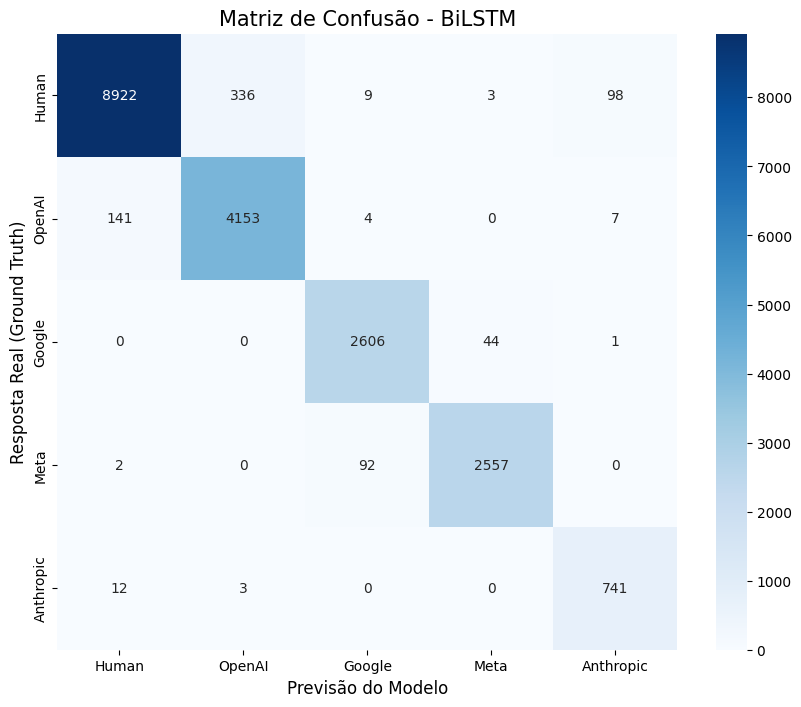


Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

       Human       0.98      0.95      0.97      9368
      OpenAI       0.92      0.96      0.94      4305
      Google       0.96      0.98      0.97      2651
        Meta       0.98      0.96      0.97      2651
   Anthropic       0.87      0.98      0.92       756

    accuracy                           0.96     19731
   macro avg       0.95      0.97      0.96     19731
weighted avg       0.96      0.96      0.96     19731



In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obter as previsões do modelo para o conjunto de validação
model_final.eval() # Garantir modo de avaliação
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model_final(inputs)
        _, predicted = torch.max(outputs, 1)
        
        y_pred_list.extend(predicted.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# 2. Criar a matriz de confusão numérica
cm = confusion_matrix(y_true_list, y_pred_list)

# 3. Mapeamento das classes (na ordem 0, 1, 2, 3, 4)
class_names = ['Human', 'OpenAI', 'Google', 'Meta', 'Anthropic']

# 4. Desenhar o gráfico (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Matriz de Confusão - BiLSTM', fontsize=15)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Resposta Real (Ground Truth)', fontsize=12)
plt.show()

# 5. (Opcional) Mostrar métricas detalhadas por classe
from sklearn.metrics import classification_report
print("\nRelatório de Classificação Detalhado:")
print(classification_report(y_true_list, y_pred_list, target_names=class_names))